## * 시각화
* 그래프를 이용하면 데이터의 구조와 패턴을 파악하기 용이하다
* 다양한 관점에서 데이터에 관한 통찰력을 제공한다

- 처음코드는 fillna=0이었으나 에러가 났고 na_values=0를 하니 에러가 안났음 (2020.8.26.)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# df = pd.read_excel('./inout_pop.xlsx', fillna=0, header=0) 
df = pd.read_excel('./inout_pop.xlsx', na_values=0, header=0)

df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226,7297099,7104398
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937,1439707,1426493
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,519334,508043,461042,478451,485710,507031,459015,439073,416095,411704
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,370817,370563,348642,351873,350213,351424,328228,321182,321158,312419


In [2]:
df = df.fillna(method='ffill')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]

# '전출지별'컬럼을 지운다 axis=1은 컬럼방향으로 지운다는 뜻
df_seoul = df_seoul.drop(['전출지별'], axis=1)
# '전입지별' 컬럼이름을 '전입지'로 바꾼다
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
# '전입지'를 인덱스로 만든다
df_seoul.set_index('전입지', inplace=True)
df_seoul.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423,1549937,1476081
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17418,18816,16135,16153,17320,17009,15062,14484,13093,12805
대구광역시,-,-,-,-,-,-,-,-,-,-,...,10277,10397,10135,10631,10062,10191,9623,8891,8446,7897
인천광역시,-,-,-,-,-,-,-,-,-,-,...,46082,51641,49640,47424,43212,44915,43745,40485,41233,38571
광주광역시,-,-,-,-,-,-,-,-,-,-,...,11095,10587,10154,9129,9759,9216,8354,7932,7378,7014


In [3]:
sr_one = df_seoul.loc['경기도']
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


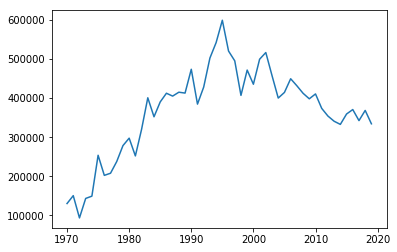

In [4]:
plt.plot(sr_one.index, sr_one.values)  # plt.plot(sr_one) 과도 같다.

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


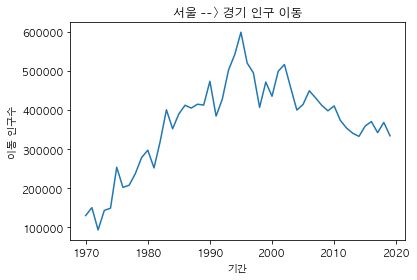

In [5]:
from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

plt.plot(sr_one.index, sr_one.values)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.show()

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


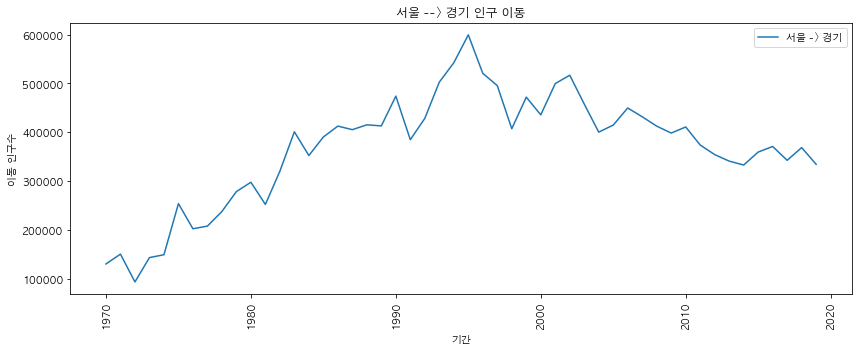

In [6]:
from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

plt.figure(figsize=(14,5))  # 가로사이즈 늘리고
plt.xticks(rotation='vertical') # 눈금 라벨 회전, 90으로 입력해도 된다

plt.plot(sr_one.index, sr_one.values)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best') #범례
plt.show()




/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


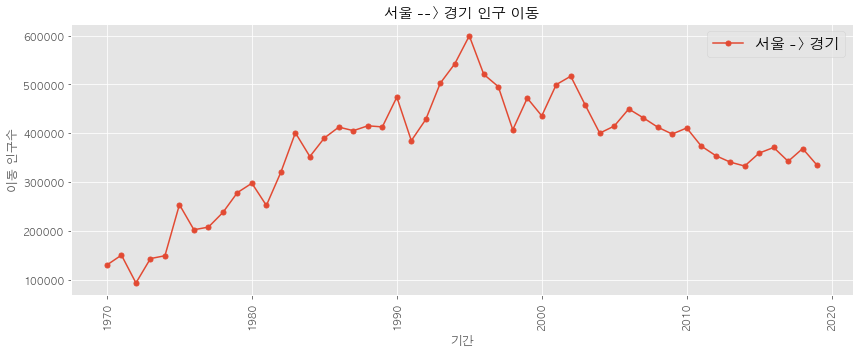

In [7]:
from matplotlib import rc
rc('font', family='AppleGothic')

# 여러가지 스타일:https://matplotlib.org/gallery/style_sheets/style_sheets_reference.html
plt.style.use('ggplot')

plt.figure(figsize=(14,5))  # 가로사이즈 늘리고
plt.xticks(size=10, rotation='vertical') # 눈금 라벨 회전, 90으로 입력해도 된다

plt.plot(sr_one.index, sr_one.values, marker='o', markersize=5)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15) #범례
plt.show()


/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


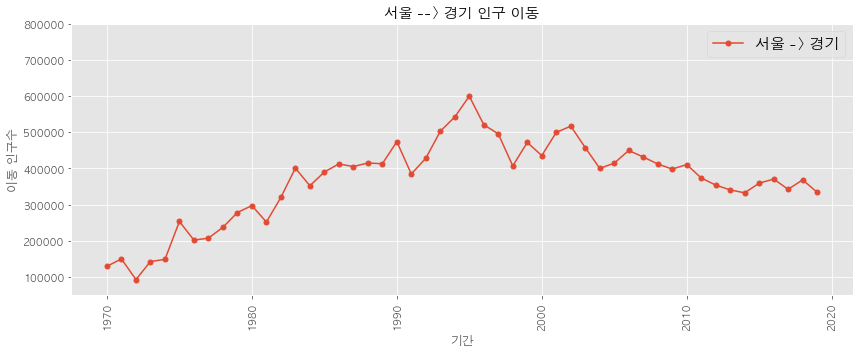

In [8]:
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')

plt.figure(figsize=(14,5))  # 가로사이즈 늘리고
plt.xticks(size=10, rotation='vertical') # 눈금 라벨 회전, 90으로 입력해도 된다

plt.plot(sr_one.index, sr_one.values, marker='o', markersize=5)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15) #범례

plt.ylim(50000, 800000)  # y축을 늘린다
# 이하 주석 코드는 에러가 난다.
# plt.annotate('',
#             xy=(47, 450000),    #  화살표 머리
#             xytext=(30, 580000), #  화살표 꼬리
#             xycoords='data',
#             arrowprops=dict(arrowstyle='->', color='skyblue', lw=5),
#             )
plt.show()

In [9]:
sr_one.index

Index(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019'],
      dtype='object')

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]


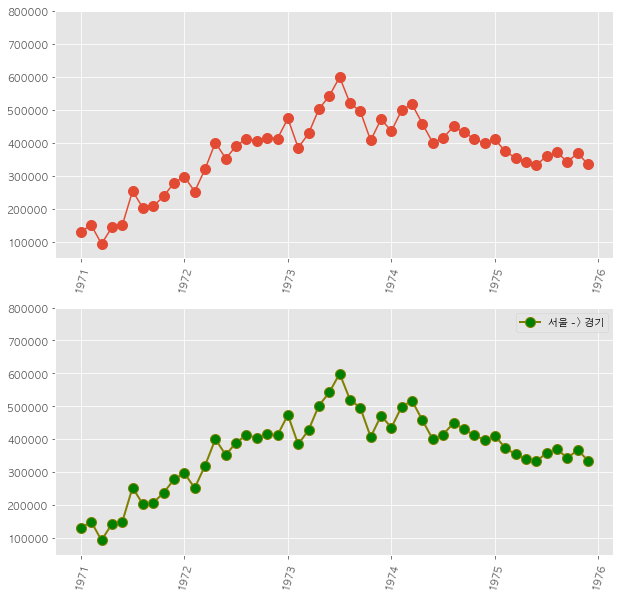

In [10]:
# 화면 분할하기 add_subplot(2행, 1열, 순서)
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')

fig = plt.figure(figsize=(10,10))  # figure: 그림틀을 만든다.
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)

ax1.plot(sr_one.index, sr_one.values, marker='o', markersize=10)
ax2.plot(sr_one.index, sr_one.values, marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 경기')
ax2.legend(loc='best')

# plt는 ylim이었는데 ax1은 set_ylim이다.
ax1.set_ylim(50000, 800000)  
ax2.set_ylim(50000, 800000) 

# plt는 xticks이었는데 ax1은 set_xticklabels이다.
ax1.set_xticklabels(sr_one.index, rotation='75') # 윈도우에서 돌려보자
ax2.set_xticklabels(sr_one.index, rotation='75')

plt.show()

## 선 그래프 꾸미기 옵션
| 꾸미기 옵션 | 설명 |
| ----
| marker | 'o', '*', '+' ,'-' | 

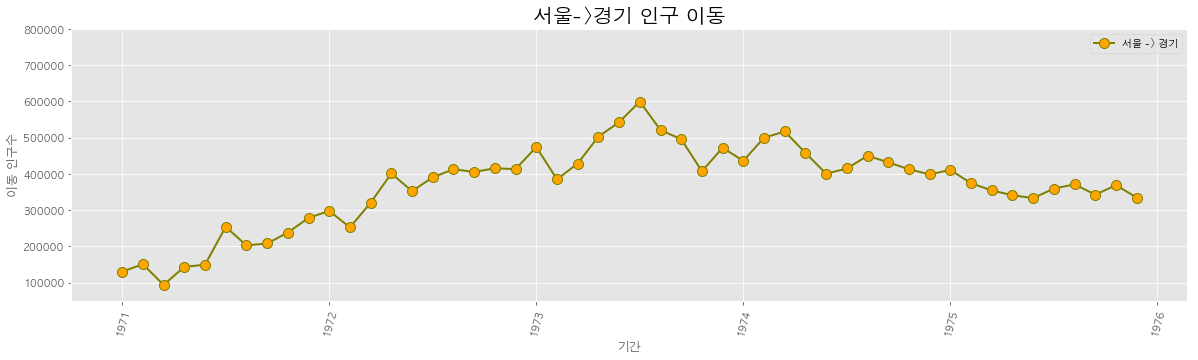

In [11]:
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(sr_one, marker='o', markerfacecolor='orange', markersize=10,
        color='olive', linewidth=2, label='서울 -> 경기')
ax.legend(loc='best')

ax.set_ylim(50000, 800000) 

ax.set_title('서울->경기 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticklabels(sr_one.index, rotation='75')

# 축 눈금 라벨 크기
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

## 같은 화면에 그래프 추가

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:252: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


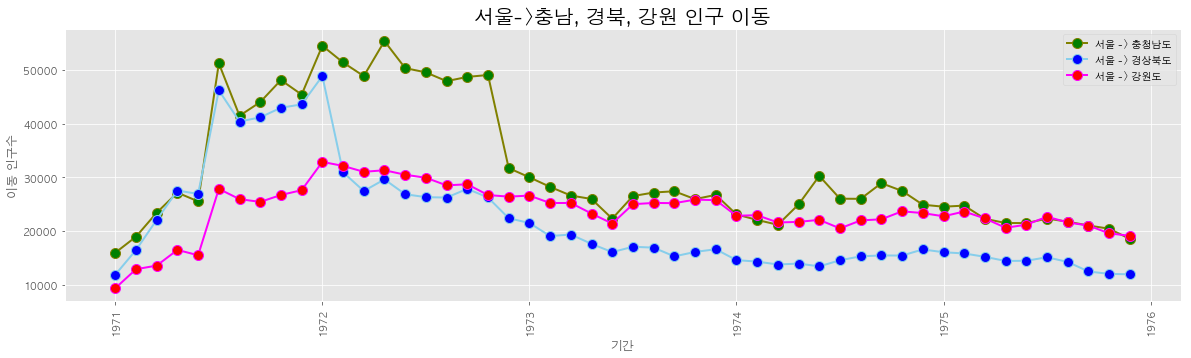

In [12]:
from matplotlib import rc
rc('font', family='AppleGothic')

col_years = list(map(str, range(1970, 2020)))
df_3 = df_seoul.loc[['충청남도','경상북도','강원도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(col_years, df_3.loc['충청남도', :], marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 충청남도')
ax.plot(col_years, df_3.loc['경상북도', :], marker='o', markerfacecolor='blue', markersize=10,
        color='skyblue', linewidth=2, label='서울 -> 경상북도')
ax.plot(col_years, df_3.loc['강원도', :], marker='o', markerfacecolor='red', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 강원도')

ax.legend(loc='best')

ax.set_title('서울->충남, 경북, 강원 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticklabels(col_years, rotation='90')

# 축 눈금 라벨 크기
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:252: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


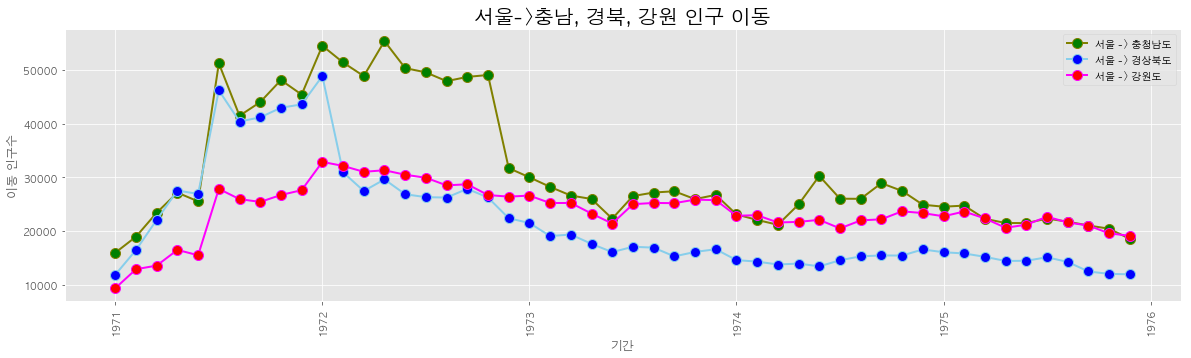

In [13]:
from matplotlib import rc
rc('font', family='AppleGothic')

col_years = list(map(str, range(1970, 2020)))
df_3 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(col_years, df_3.loc['충청남도', :], marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 충청남도')
ax.plot(col_years, df_3.loc['경상북도', :], marker='o', markerfacecolor='blue', markersize=10,
        color='skyblue', linewidth=2, label='서울 -> 경상북도')
ax.plot(col_years, df_3.loc['강원도', :], marker='o', markerfacecolor='red', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 강원도')

ax.legend(loc='best')

ax.set_title('서울->충남, 경북, 강원 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticklabels(col_years, rotation='90')

# 축 눈금 라벨 크기
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

In [14]:
ax.set_xticklabels(col_years, rotation='90')

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:252: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


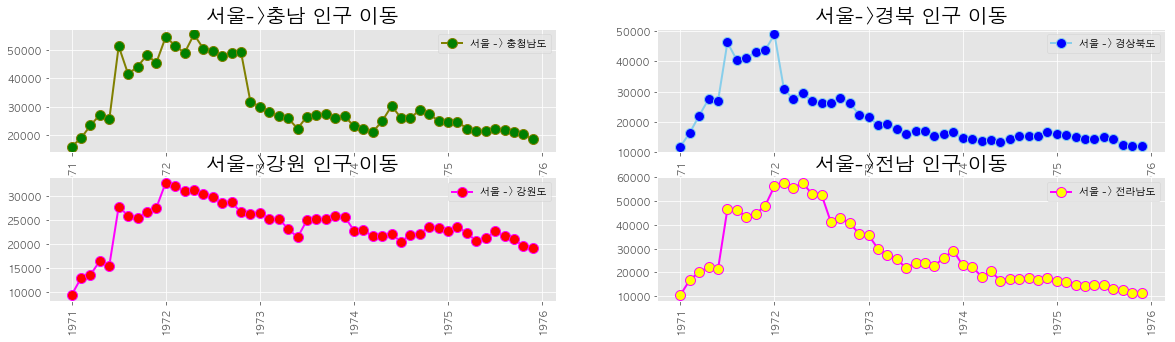

In [15]:
from matplotlib import rc
rc('font', family='AppleGothic')

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

ax1.plot(col_years, df_4.loc['충청남도', :], marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 충청남도')
ax2.plot(col_years, df_4.loc['경상북도', :], marker='o', markerfacecolor='blue', markersize=10,
        color='skyblue', linewidth=2, label='서울 -> 경상북도')
ax3.plot(col_years, df_4.loc['강원도', :], marker='o', markerfacecolor='red', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 강원도')
ax4.plot(col_years, df_4.loc['전라남도', :], marker='o', markerfacecolor='yellow', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 전라남도')

ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax4.legend(loc='best')

ax1.set_title('서울->충남 인구 이동', size=20)
ax2.set_title('서울->경북 인구 이동', size=20)
ax3.set_title('서울->강원 인구 이동', size=20)
ax4.set_title('서울->전남 인구 이동', size=20)

ax1.set_xticklabels(col_years, rotation='90')
ax2.set_xticklabels(col_years, rotation='90')
ax3.set_xticklabels(col_years, rotation='90')
ax4.set_xticklabels(col_years, rotation='90')

plt.show()

## 면적그래프 그리기

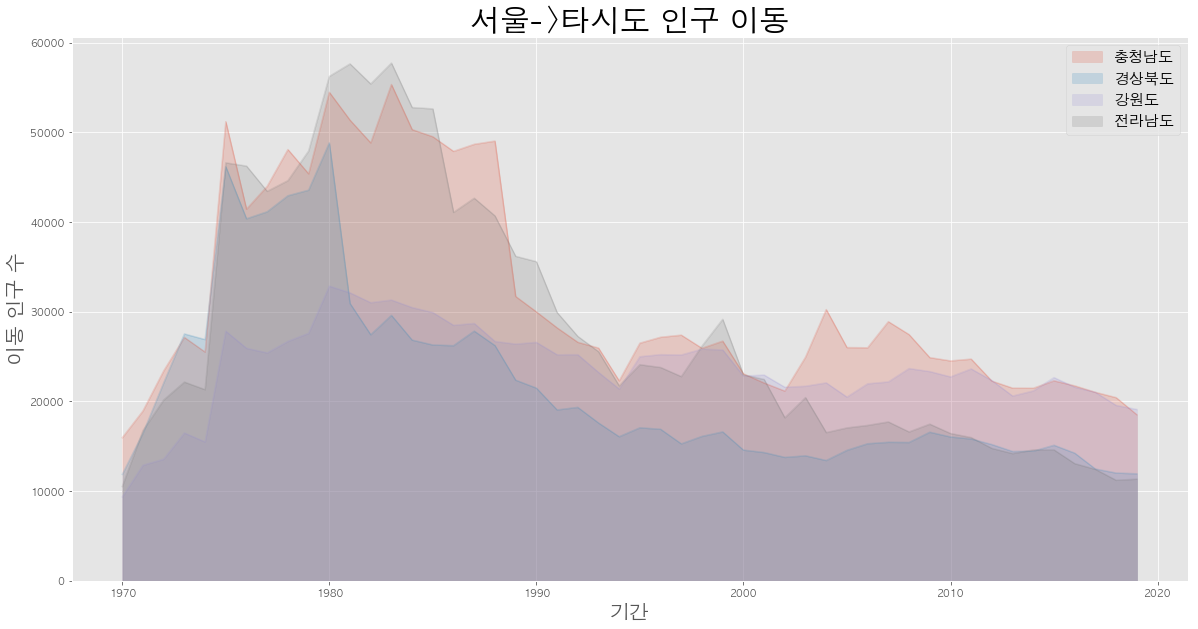

In [16]:
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

df_4.plot(kind='area', stacked=False, alpha=0.2, figsize=(20,10))

plt.title('서울->타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)

plt.show()

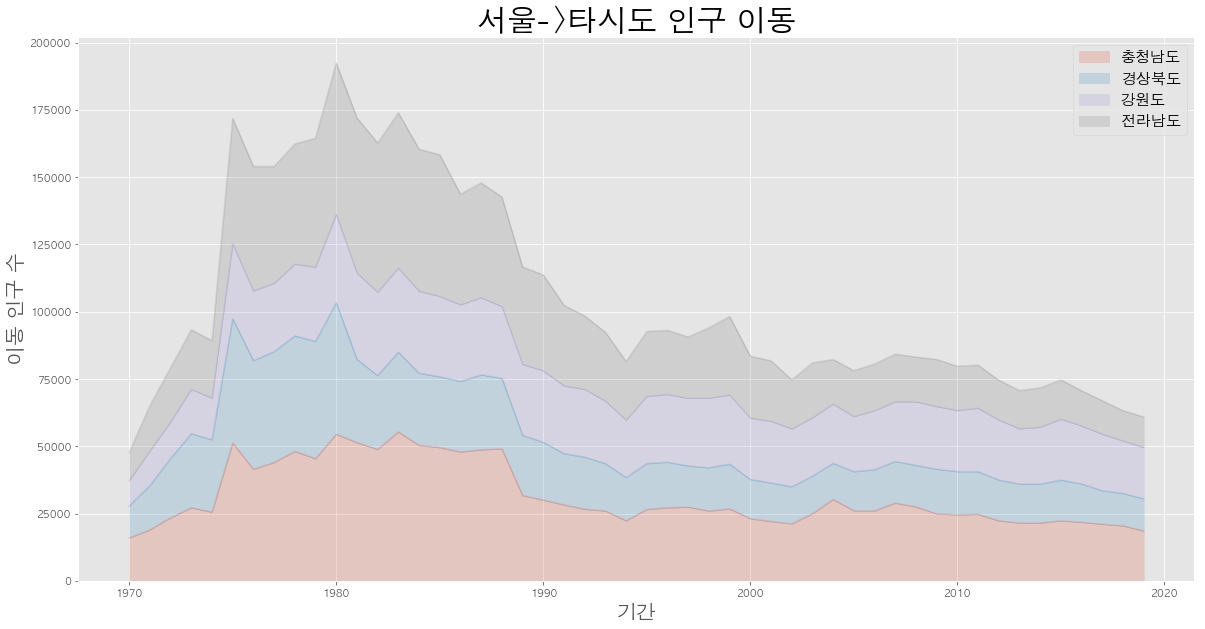

In [17]:
# 겹쳐 그리기 (누적) stacked=True
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20,10))

plt.title('서울->타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)

plt.show()

<class 'matplotlib.axes._subplots.AxesSubplot'>


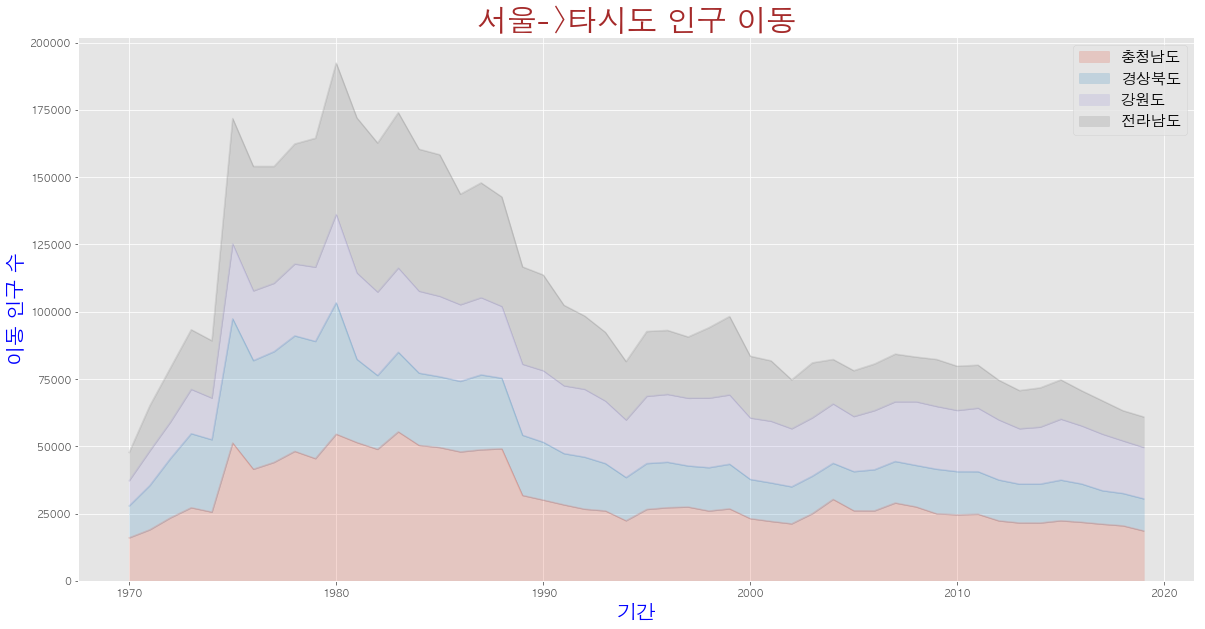

In [18]:
# axe 객체 속성 변경하기 
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

# df_4.plot을 통해 ax객체를 받아온다.
ax = df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20,10))
print(type(ax))

ax.set_title('서울->타시도 인구 이동', size=30, color='brown', weight='bold')
ax.set_ylabel('이동 인구 수', size=20, color='blue')
ax.set_xlabel('기간', size=20, color='blue')
ax.legend(loc='best', fontsize=15)

plt.show()

# 막대 그래프 그리기

In [19]:
df_seoul.loc[['충청남도','경상북도','강원도','전라남도']]

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,24522,24723,22269,21486,21473,22299,21741,21020,20426,18522
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,16042,15818,15191,14420,14456,15113,14236,12464,12017,11935
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,22736,23624,22332,20601,21173,22659,21590,21016,19558,19105
전라남도,10513,16755,20157,22160,21314,46610,46251,43430,44624,47934,...,16429,15974,14765,14187,14591,14598,13065,12426,11209,11334


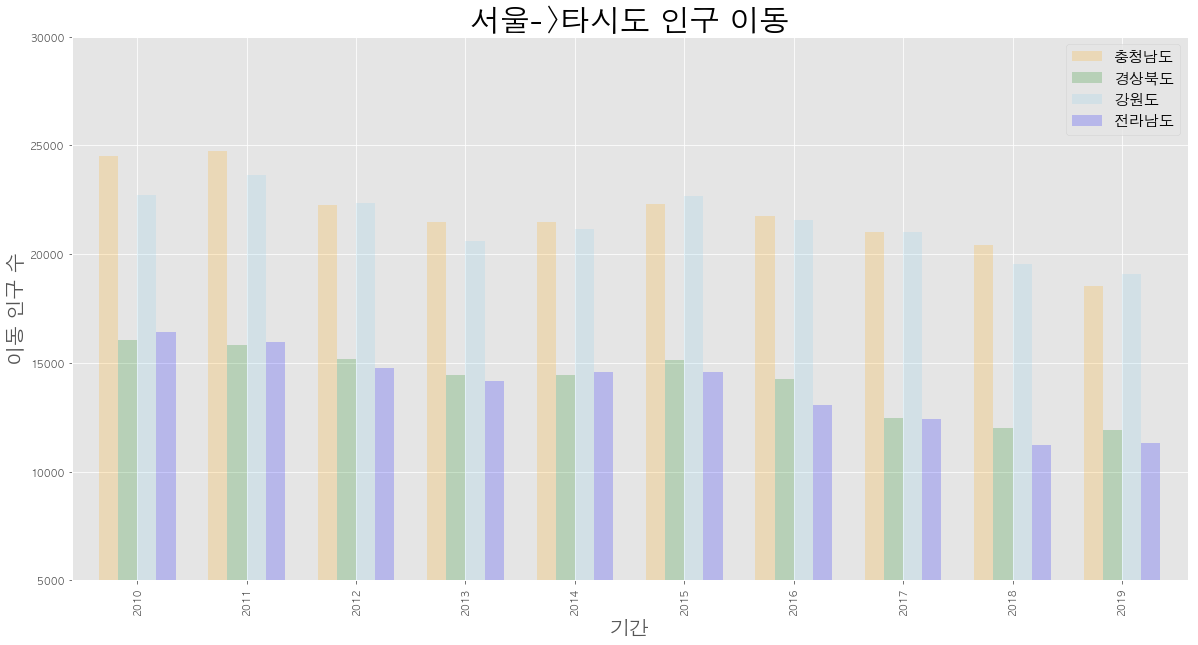

In [20]:
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 1970부터 2020까지 숫자를 문자로(str 함수)로 변환해서 리스트로 만든다
col_years = list(map(str, range(2010, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

# df_4.plot을 통해 ax객체를 받아온다.
df_4.plot(kind='bar', width=0.7, color=['orange','green','skyblue','blue'], 
        alpha=0.2, figsize=(20,10))

plt.title('서울->타시도 인구 이동', size=30,weight='bold')
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.ylim(5000, 30000)
plt.legend(loc='best', fontsize=15)

plt.show()

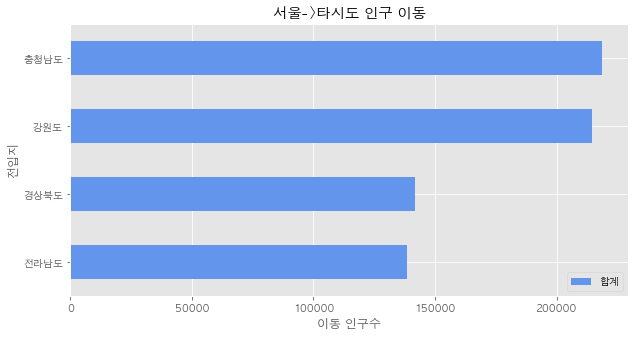

In [21]:
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 1970부터 2020까지 숫자를 문자로(str 함수)로 변환해서 리스트로 만든다
col_years = list(map(str, range(2010, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4['합계'] = df_4.sum(axis=1)
df_total = df_4[['합계']].sort_values(by='합계', ascending=True)

plt.style.use('ggplot')

df_total.plot(kind='barh', width=0.5, color='cornflowerblue', figsize=(10,5))

plt.title('서울->타시도 인구 이동')
plt.ylabel('전입지')
plt.xlabel('이동 인구수')

plt.show()

## 오류: 수정 필요

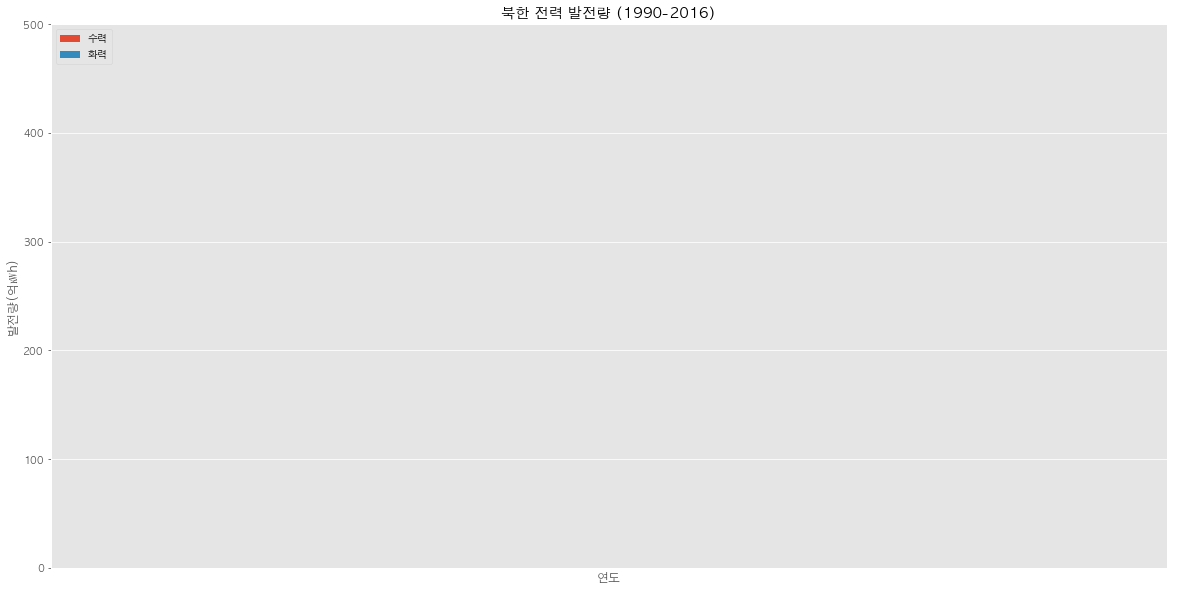

In [22]:
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('./남북한발전전력량.xlsx', convert_float=True)
df = df.loc[5:9]  # 북한만 가져온다.

df.drop('전력량 (억㎾h)', axis='columns', inplace=True)
df.set_index('발전 전력별', inplace=True)
df = df.T

#증감률(변동률) 계산
df = df.rename(columns={'합계':'총발전량'})
df['총발전량 - 1년'] = df['총발전량'].shift(1)
df['증감률'] = ((df['총발전량'] / df['총발전량 - 1년']) - 1) * 100

# 2축 그래프 그리기
ax1 = df[['수력','화력']].plot(kind='bar', figsize=(20,10), width=0.7, stacked=True)
# ax2 = ax1.twinx()
# ax2.plot(df.index, df['증감률'], linestyle='--', marker='o', markersize=20,
#         color='red', label='전년대비 증감률(%)')

ax1.set_xlim(len(df.index))
ax1.set_ylim(0, 500)
# ax2.set_xlim(len(df.index))
# ax2.set_ylim(-50, 50)


ax1.set_xlabel('연도')
ax1.set_ylabel('발전량(억㎾h)')
# ax2.set_ylabel('전년대비 증감률(%)')

plt.title('북한 전력 발전량 (1990-2016)')
ax1.legend(loc='upper left')

plt.show()

/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/cbook.py:2224: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:252: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


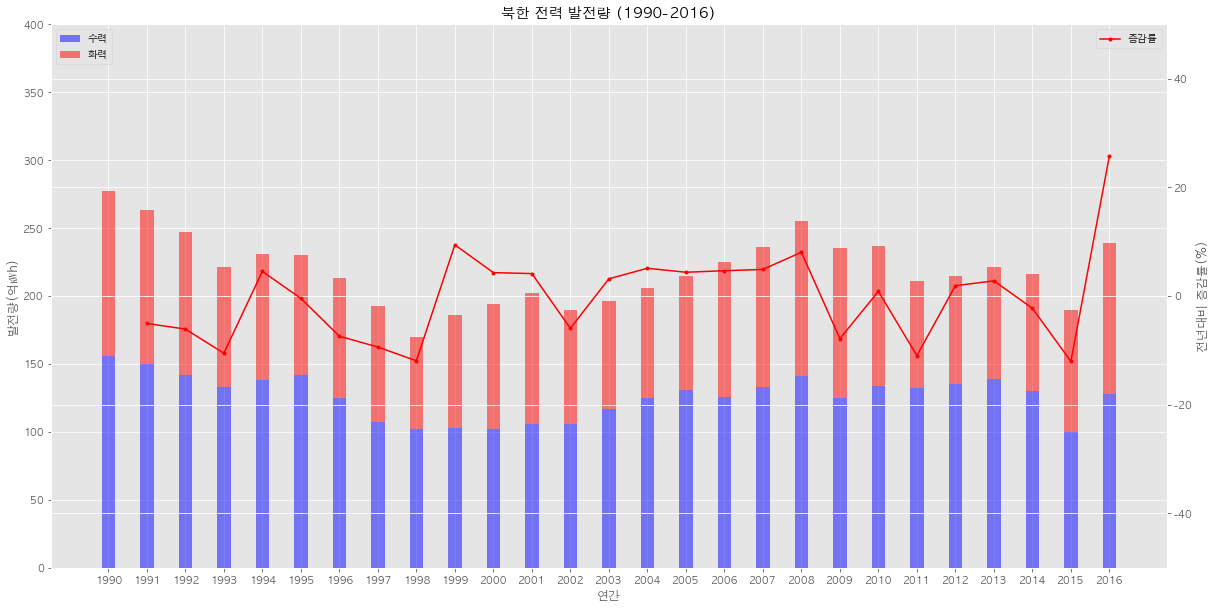

In [23]:
# 완성된 그래프는 아래와 같이 깔끔하게 보고서에 적용할 수 있는 모양으로 만들어 낼 수 있다. 더 다양한 그래프를 그리기 위해 참고 할 만한 사이트는 다음과 같다.

# http://matplotlib.org/users/screenshots.html


# 기본 Bar Chart 예제 2 ..................
import numpy as np
import matplotlib.pyplot as plt
import numpy as array

y1_value = df['수력']
y11_value = df['화력']
x_name= df.index
n_groups = len(x_name)

index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.5

plt.figure(figsize=(20,10))
plt.bar(index, y1_value, bar_width, tick_label=x_name, align='center',
        alpha=opacity, color='b', label='수력')
# 누적 막대 그래프를 그리려면 bottom을 아래 값을로 지정해 준다.
plt.bar(index, y11_value, bar_width, tick_label=x_name, align='center',
        alpha=opacity, color='r', label='화력', bottom=y1_value)

plt.xlabel('연간')
plt.ylabel('발전량(억㎾h)')
plt.xlim( -1, n_groups)
plt.ylim( 0, 400)
plt.legend(loc='upper left')

# twin axis ....
plt.twinx()
y2_value = df['증감률']
plt.plot(index, y2_value, 'r.-')
plt.ylabel('전년대비 증감률(%)')
plt.ylim(-50, 50)

plt.title('북한 전력 발전량 (1990-2016)')
plt.legend(loc='upper right')

plt.show()


## 히스토그램


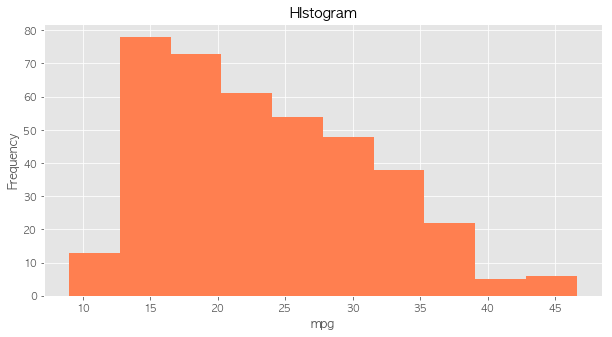

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

df = pd.read_csv('./auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight','acceleration'
              ,'model year','origin','name']
df['mpg'].plot(kind='hist', bins=10, color='coral', figsize=(10,5))

plt.title('HIstogram')
plt.xlabel('mpg')
plt.show()

In [25]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## 산점도
* 변수가 2개

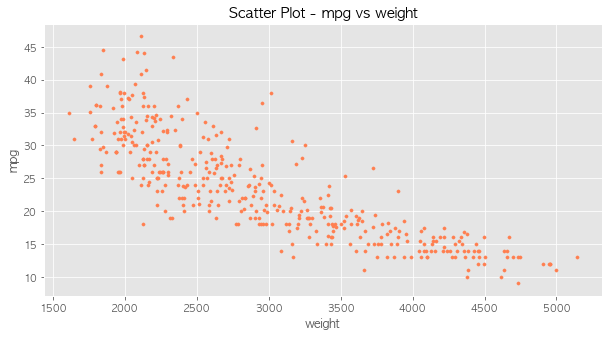

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

df = pd.read_csv('./auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight','acceleration'
              ,'model year','origin','name']

df.plot(kind='scatter', x='weight', y='mpg', c='coral', s=10, figsize=(10,5))
plt.title('Scatter Plot - mpg vs weight')

plt.show()

* 변수가 1개 더 추가시 점의 크기의 변화를 줄 수 있다.

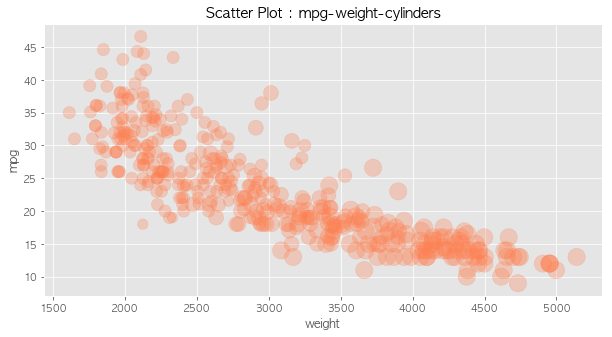

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

df = pd.read_csv('./auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight','acceleration'
              ,'model year','origin','name']

# 점의 크기를 s에 넘겨준다
cylinders_size = df.cylinders / df.cylinders.max() * 300
df.plot(kind='scatter', x='weight', y='mpg', c='coral', figsize=(10,5),
       s=cylinders_size, alpha=0.3)
plt.title('Scatter Plot : mpg-weight-cylinders')

plt.show()

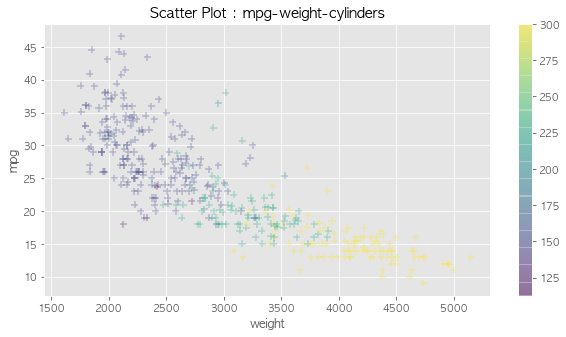

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

df = pd.read_csv('./auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight','acceleration'
              ,'model year','origin','name']

# 점의 모양을 +로 바꾸고 크기는 동일하다.
# color를 색을 기준으로 분류를 한다.
cylinders_size = df.cylinders / df.cylinders.max() * 300
df.plot(kind='scatter', x='weight', y='mpg', marker='+', figsize=(10,5),
       cmap='viridis', c=cylinders_size, s=50, alpha=0.3)
plt.title('Scatter Plot : mpg-weight-cylinders')

plt.show()

## 파이 차트


           mpg  cylinders  displacement    weight  acceleration  model year  \
origin                                                                        
1       5000.8       1556       61229.5  837121.0        3743.4       18827   
2       1952.4        291        7640.0  169631.0        1175.1        5307   
3       2405.6        324        8114.0  175477.0        1277.6        6118   

        count  
origin         
1         249  
2          70  
3          79  


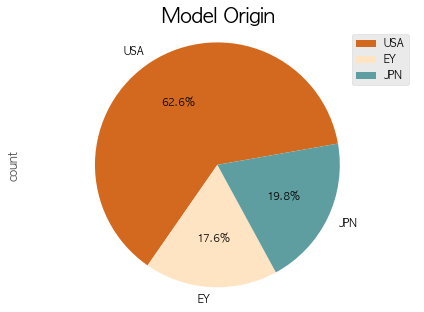

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

df = pd.read_csv('./auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight','acceleration'
              ,'model year','origin','name']

df['count'] = 1
df_origin = df.groupby('origin').sum() #origin의 열을 기준으로 그룹화, 합계 연산
print(df_origin.head())

df_origin.index = ['USA','EY','JPN']
df_origin['count'].plot(kind='pie', figsize=(7,5), autopct='%1.1f%%',
                       startangle=10, colors=['chocolate','bisque','cadetblue'])
plt.title('Model Origin', size=20)
plt.axis('equal')
plt.legend(labels=df_origin.index, loc='upper right')
plt.show()

## 박스 플롯
* 범주형 데이터의 분포
(최소값, 1분위값, 중간값, 3분위값, 최대값)

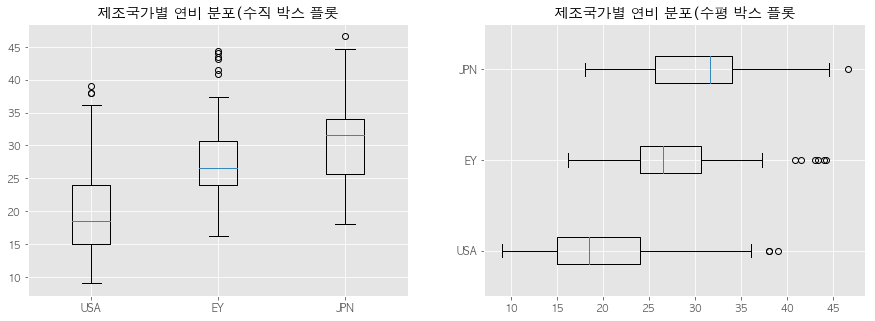

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')
# plt.style.use('seaborn-poster')
plt.rcParams['axes.unicode_minus']=False #마이너스 부호 출력 설정

df = pd.read_csv('./auto-mpg.csv', header=None)

df.columns = ['mpg','cylinders','displacement','horsepower','weight','acceleration'
              ,'model year','origin','name']

#그래프 객체 생성 : figure에 2개의 서브플롯 생성
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.boxplot(x=[df[df['origin']==1]['mpg'],
           df[df['origin']==2]['mpg'],
           df[df['origin']==3]['mpg']],
           labels=['USA','EY','JPN'])
ax2.boxplot(x=[df[df['origin']==1]['mpg'],
           df[df['origin']==2]['mpg'],
           df[df['origin']==3]['mpg']],
           labels=['USA','EY','JPN'],
           vert=False)

ax1.set_title('제조국가별 연비 분포(수직 박스 플롯')
ax2.set_title('제조국가별 연비 분포(수평 박스 플롯')

plt.show()

# seaborn 라이브러리 (matplotlib의 기능과 스타일 확장)

In [1]:
import seaborn as sns

titanic = sns.load_dataset('titanic')

print(titanic.head())
print('\n')
print(titanic.info())

Matplotlib is building the font cache; this may take a moment.

Bad key text.latex.unicode in file /Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 112 ('text.latex.unicode : False # use "ucs" and "inputenc" LaTeX packages for handling')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.1/matplotlibrc.template
or from the matplotlib source distribution

Bad key text.dvipnghack in file /Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 127 ("text.dvipnghack : None      # some versions of dvipng don't handle alpha")
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.1/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.frameon in file /Users/jihyunyang/anaconda3/lib/python3.6/site-packages/matplotlib/mpl-data/stylel

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-

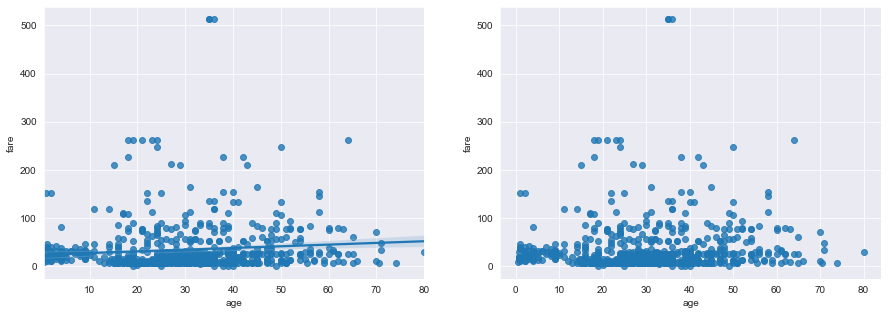

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_style('darkgrid')

fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

sns.regplot(x='age', y='fare', data=titanic, ax=ax1)
sns.regplot(x='age', y='fare', data=titanic, ax=ax2, fit_reg=False) # 회귀선 미표시

plt.show()


## 히스토그램/커널 밀도 그래프
* 단변수 데이터 분포
* 커널 밀도 그래프: 그래프와 x 축 사이의 면적이 1이 되도록 그리는 밀도 분포 그래프

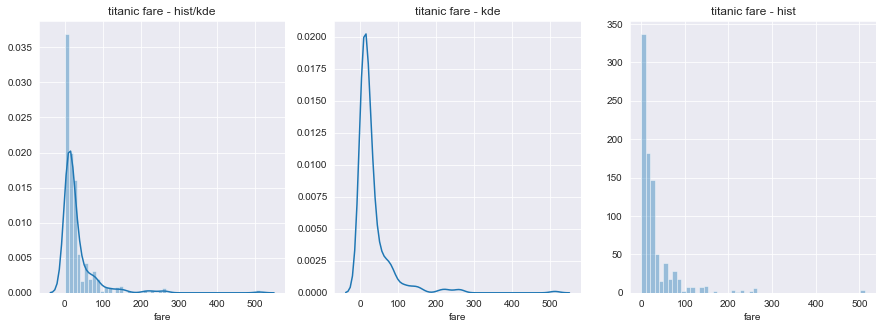

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_style('darkgrid')

fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

sns.distplot(titanic['fare'], ax=ax1)
sns.distplot(titanic['fare'], hist=False, ax=ax2)
sns.distplot(titanic['fare'], kde=False, ax=ax3)

ax1.set_title('titanic fare - hist/kde')
ax2.set_title('titanic fare - kde')
ax3.set_title('titanic fare - hist')

plt.show()


## 히트맵
* 2개의 범주 변수를 x, y
* 나머지 값을 색으로 표시

In [ ]:
titanic.head()

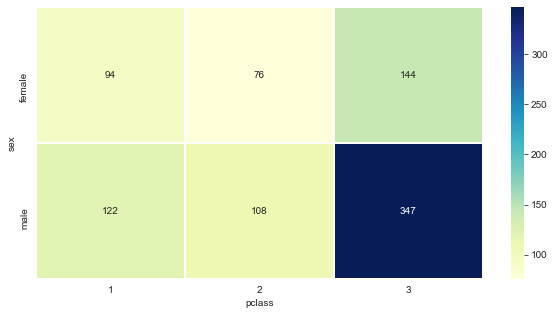

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_style('darkgrid')

plt.figure(figsize=(10,5))

table = titanic.pivot_table(index=['sex'], columns=['pclass'], aggfunc='size')
sns.heatmap(table, annot=True, fmt='d', cmap='YlGnBu', linewidth=.5, cbar=True)

plt.show()


## 범주형 데이터의 산점도
* stripplot() 
* swarmplot() : 데이터의 분산까지 고려, 데이터 포인트가 서로 중복되지 않도록 그린다, 입체적

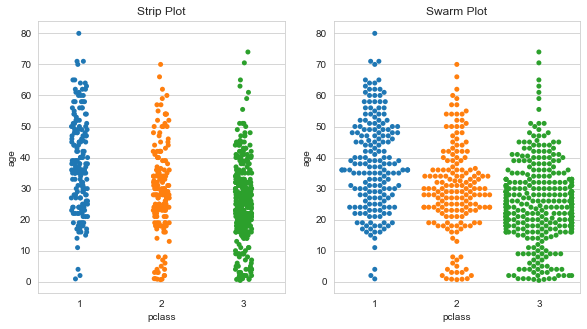

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_style('whitegrid')

fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)

sns.stripplot(x='pclass', y='age', data=titanic, ax=ax1)
sns.swarmplot(x='pclass', y='age', data=titanic, ax=ax2)

ax1.set_title('Strip Plot')
ax2.set_title('Swarm Plot')


plt.show()

## 막대 그래프

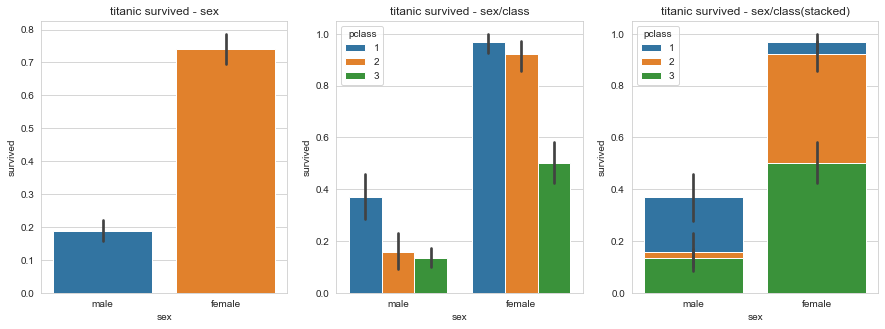

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
sns.set_style('whitegrid')

fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

sns.barplot(x='sex', y='survived', data=titanic, ax=ax1)
sns.barplot(x='sex', y='survived', hue='pclass', data=titanic, ax=ax2)
sns.barplot(x='sex', y='survived', hue='pclass', dodge=False, data=titanic, ax=ax3)

ax1.set_title('titanic survived - sex')
ax2.set_title('titanic survived - sex/class')
ax3.set_title('titanic survived - sex/class(stacked)')

plt.show()

In [7]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
titanic.groupby(by=['sex','survived']).count()

pclass  age  sibsp  parch  fare  embarked  class  who  \
sex    survived                                                          
female 0             81   64     81     81    81        81     81   81   
       1            233  197    233    233   233       231    233  233   
male   0            468  360    468    468   468       468    468  468   
       1            109   93    109    109   109       109    109  109   

                 adult_male  deck  embark_town  alive  alone  
sex    survived                                               
female 0                 81     6           81     81     81  
       1                233    91          231    233    233  
male   0                468    61          468    468    468  
       1                109    45          109    109    109

## 빈도 그래프 
* 각 범주에 속하는 데이터 개수를 막대 그래프로 나타내는 countplot()
* barplot은 y값을 설정할수 있지만 countplot은 안된다.
* countplot은 float값을 쓸수 없다.
* countplot은 데이터프레임만 쓸 수 있다.

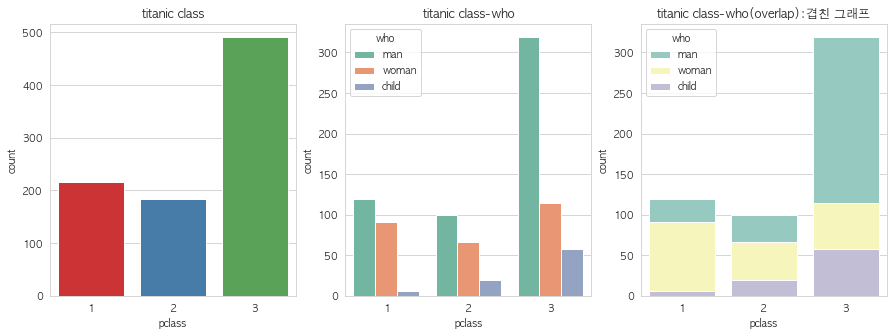

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

titanic = sns.load_dataset('titanic')
# sns.set_style('whitegrid')

fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

sns.countplot(x='pclass', palette='Set1', data=titanic, ax=ax1)
sns.countplot(x='pclass', hue='who', palette='Set2', data=titanic, ax=ax2)
sns.countplot(x='pclass', hue='who', palette='Set3', dodge=False, data=titanic, ax=ax3)
#dodge는 stacked가 아니고 겹쳐진 그래프이다.
ax1.set_title('titanic class')
ax2.set_title('titanic class-who')
ax3.set_title('titanic class-who(overlap):겹친 그래프')

plt.show()

In [11]:
titanic.groupby(by='pclass').count()

,survived,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
pclass,,,,,,,,,,,,,,
1,216,216,186,216,216,216,214,216,216,216,175,214,216,216
2,184,184,173,184,184,184,184,184,184,184,16,184,184,184
3,491,491,355,491,491,491,491,491,491,491,12,491,491,491


## 박스플롯/바이올린 그래프
* 데이터 분포와 주요 통계지표를 함께 제공
* 박스플롯: 분산의 정도를 정확하게 알기 어려우므로 커널밀도 함수 그래프를 추가하여 바이올린 그래프를 그리는 경우가 있음

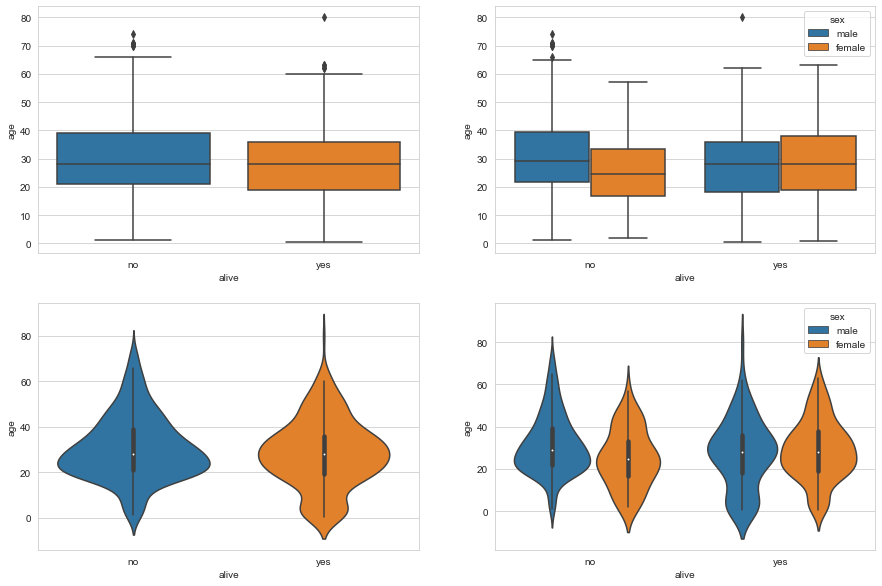

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

titanic = sns.load_dataset('titanic')
sns.set_style('whitegrid')

fig = plt.figure(figsize=(15,10))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

sns.boxplot(x='alive', y='age', data=titanic, ax=ax1)
sns.boxplot(x='alive', y='age', hue='sex', data=titanic, ax=ax2)
sns.violinplot(x='alive', y='age', data=titanic, ax=ax3)
sns.violinplot(x='alive', y='age', hue='sex', data=titanic, ax=ax4)

plt.show()

## 조인트 그래프
* jointplot() : 산점도를 기본, x-y축에 각 변수에 대한 히스토그램을 동시에 보여준다


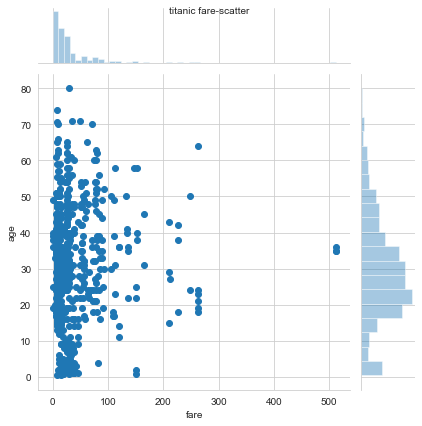

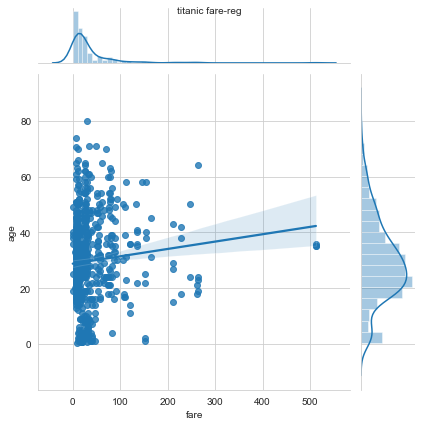

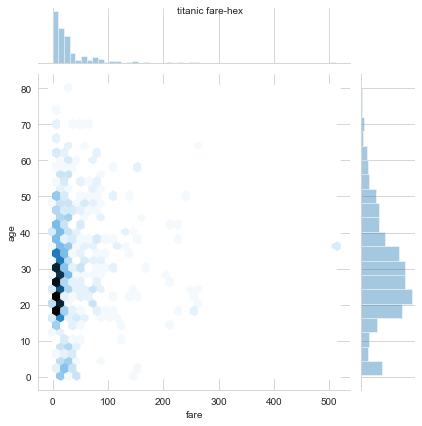

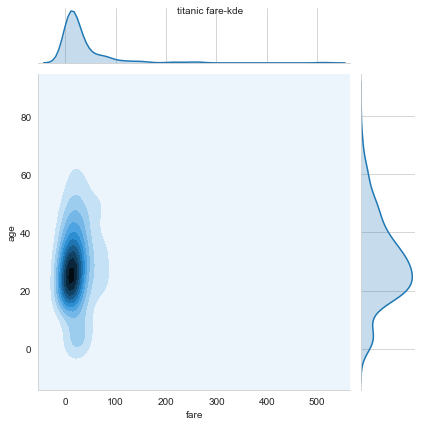

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

titanic = sns.load_dataset('titanic')
sns.set_style('whitegrid')

j1 = sns.jointplot(x='fare', y='age', data=titanic)
j2 = sns.jointplot(x='fare', y='age', kind='reg', data=titanic)
j3 = sns.jointplot(x='fare', y='age', kind='hex', data=titanic)
j4 = sns.jointplot(x='fare', y='age', kind='kde', data=titanic)

j1.fig.suptitle('titanic fare-scatter', size=10)
j2.fig.suptitle('titanic fare-reg', size=10)
j3.fig.suptitle('titanic fare-hex', size=10)
j4.fig.suptitle('titanic fare-kde', size=10)

plt.show()

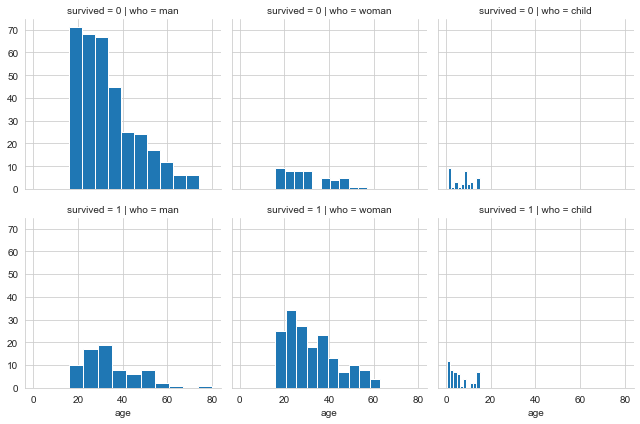

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

titanic = sns.load_dataset('titanic')
sns.set_style('whitegrid')

g = sns.FacetGrid(data=titanic, col='who', row='survived')

g = g.map(plt.hist, 'age')

## 이변수 데이터 분포
* pairplot() : 열(변수)을 두개씩 짝지어서 모든 조합에 대해 표현
* 대각선의 막대 그래프는 분포를 나타낸다고 본다.

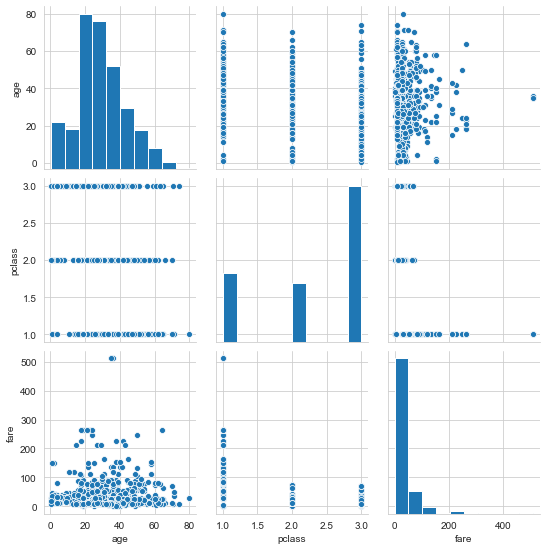

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

titanic = sns.load_dataset('titanic')
sns.set_style('whitegrid')

titanic_pair = titanic[['age','pclass','fare']]
g = sns.pairplot(titanic_pair)

# Folium 라이브러니 - 지도 활용
* 지도는 zoom과 scroll이 가능하다
* 오직 웹 환경에서만 지도를 확인할 수 있다 (주피터 기반인 경우 바로 확인, 다른IDE는 save()하여 HTML저장후 확인



In [19]:
import folium

seoul_map = folium.Map(location=[37.55,126.98], zoom_start=12)
# seoul_map = folium.Map(location=[37.55,126.98], tiles='Stamen Terrain', zoom_start=12)
# seoul_map = folium.Map(location=[37.55,126.98], tiles='Stamen Toner', zoom_start=12)
seoul_map
# seoul_map.save('./seoul.html')

## 지도에 마커 표시하기

In [33]:
import pandas as pd
import folium

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

df = pd.read_excel('./서울지역대학교위치.xlsx', names=['이름','위도','경도'], header=1)
seoul_map = folium.Map(location=[37.55,126.98], tiles='Stamen Terrain', zoom_start=12)


for name, lat, lng in zip(df.이름, df.위도, df.경도):
    folium.Marker([lat, lng], popup=name).add_to(seoul_map)
    
#파일을 저장하면 브라우저에서 볼수 있다.
seoul_map.save('./seoul_colleges1.html')

In [34]:
import pandas as pd
import folium

from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

df = pd.read_excel('./서울지역대학교위치.xlsx', names=['이름','위도','경도'], header=1)
seoul_map = folium.Map(location=[37.55,126.98], tiles='Stamen Terrain', zoom_start=12)


for name, lat, lng in zip(df.이름, df.위도, df.경도):
    folium.CircleMarker([lat, lng], radius=10, color='brown', fill=True,
                        fill_color='coral', fill_opacity=0.7, popup=name).add_to(seoul_map)

seoul_map

## 단계구분도 Choropleth Map 표시하기

In [44]:
import pandas as pd
import folium
import json

file_path='./경기도인구데이터.xlsx'
df = pd.read_excel(file_path, index_col='구분')
df.columns = df.columns.map(str)

geo_path = './경기도행정구역경계.json'
try:
    geo_data = json.load(open(geo_path, encoding='utf-8'))
except:
    geo_data = json.load(open(geo_path, encoding='utf-8-sig'))
    

g_map = folium.Map(location=[37.5502, 126.982],
                  tiles='Stamen Terrain', zoom_start=9)
year = '2017'

folium.Choropleth(geo_data=geo_data,
                 data = df[year],
                 columns = ['구분', year],
                 fill_color='YlOrRd', fill_opacity=0.7, line_opacity=0.3,
                 threshold_scale=[10000,100000,300000,500000,700000],
                 key_on='feature.properties.name').add_to(g_map)

g_map

In [61]:
file_path='./서울인구데이터.xlsx'
df = pd.read_excel(file_path)
df.drop([0,1], axis=0, inplace=True)
df.rename(columns={'행정구역(시군구)별':'구분'}, inplace=True)
df.head()

,구분,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
2,종로구,165846,170705,168603,170578,168382,165207,160070,156993,154986,152737,154770,153065,151290
3,중구,130044,130362,129465,132822,133193,133360,130465,128065,125733,125249,125709,125725,126171
4,용산구,235832,238224,238708,244853,246501,243232,239740,235951,233342,230241,229161,228999,228670
5,성동구,333535,314212,308058,309093,300711,299604,299337,296086,297003,299259,304808,308221,300889
6,광진구,376572,375482,373998,375463,371936,371313,368927,363354,360369,357215,357703,355559,351350


In [66]:
import pandas as pd
import folium
import json

file_path='./서울인구데이터.xlsx'
df = pd.read_excel(file_path)
df.drop([0,1], axis=0, inplace=True)
df.rename(columns={'행정구역(시군구)별':'구분'}, inplace=True)
df.columns = df.columns.map(str)

geo_path = './서울행정구역경계.json'
try:
    geo_data = json.load(open(geo_path, encoding='utf-8'))
except:
    geo_data = json.load(open(geo_path, encoding='utf-8-sig'))
    
geo_data
# g_map = folium.Map(location=[37.5502, 126.982],
#                   tiles='Stamen Terrain', zoom_start=9)
# year = '2007'

# folium.Choropleth(geo_data=geo_data,
#                  data = df[year],
#                  columns = ['구분', year],
#                  fill_color='YlOrRd', fill_opacity=0.7, line_opacity=0.3,
#                  threshold_scale=[10000,100000,300000,500000,700000],
#                  key_on='DATA.sig_kor_nm').add_to(g_map)

# g_map

{'DESCRIPTION': {'LAT': '위도',
  'ESRI_PK': 'ESRI_PK',
  'SIG_KOR_NM': '시군구명_한글',
  'SIG_CD': '시군구코드',
  'SIG_ENG_NM': '시군구명_영문',
  'LNG': '경도',
  'OBJECTID': '순번'},
 'DATA': [{'esri_pk': 0,
   'sig_eng_nm': 'Dobong-gu',
   'lng': '127.0317674',
   'sig_cd': '11320',
   'sig_kor_nm': '도봉구',
   'objectid': 1,
   'lat': '37.6658609'},
  {'esri_pk': 1,
   'sig_eng_nm': 'Eunpyeong-gu',
   'lng': '126.9227004',
   'sig_cd': '11380',
   'sig_kor_nm': '은평구',
   'objectid': 2,
   'lat': '37.6176125'},
  {'esri_pk': 2,
   'sig_eng_nm': 'Dongdaemun-gu',
   'lng': '127.0507003',
   'sig_cd': '11230',
   'sig_kor_nm': '동대문구',
   'objectid': 3,
   'lat': '37.5838012'},
  {'esri_pk': 3,
   'sig_eng_nm': 'Dongjak-gu',
   'lng': '126.9443073',
   'sig_cd': '11590',
   'sig_kor_nm': '동작구',
   'objectid': 4,
   'lat': '37.4965037'},
  {'esri_pk': 4,
   'sig_eng_nm': 'Geumcheon-gu',
   'lng': '126.9001546',
   'sig_cd': '11545',
   'sig_kor_nm': '금천구',
   'objectid': 5,
   'lat': '37.4600969'},
  {'esri_p